In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import BatchNormalization



In [ ]:
#load the data set
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()

# split the data set in train subset and validation subset
# we know from the dataset docomentation that Mnist Fashion dataset has 60.000 instances for training and 10.000 instances for testing
(X_train, y_train), (X_test, y_test) = fashion_mnist

# Use the last 10,000 instances of the training subset as the validation subset
X_train, X_valid = X_train[:-10000], X_train[-10000:]
y_train, y_valid = y_train[:-10000], y_train[-10000:]


In [51]:


#  Class names for the Fashion MNIST dataset
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Create a function to calculate class distribution
def get_class_distribution(labels, class_names):
    unique, counts = np.unique(labels, return_counts=True)
    return dict(zip([class_names[i] for i in unique], counts))

# Get class distributions
train_dist = get_class_distribution(y_train, class_names)
val_dist = get_class_distribution(y_valid, class_names)
test_dist = get_class_distribution(y_test, class_names)

# Sorting with Pandas DataFrame
df_distribution = pd.DataFrame([train_dist, val_dist, test_dist], 
                               index=['Training', 'Validation', 'Test'])
df_distribution = df_distribution.sort_index(axis=1)  
print(df_distribution)


    

            Ankle boot   Bag  Coat  Dress  Pullover  Sandal  Shirt  Sneaker  \
Training          4979  5032  4950   4979      4992    5004   5030     5045   
Validation        1021   968  1050   1021      1008     996    970      955   
Test              1000  1000  1000   1000      1000    1000   1000     1000   

            T-shirt/top  Trouser  
Training           4977     5012  
Validation         1023      988  
Test               1000     1000  


In [52]:

# Print pixel range (minimum and maximum)
print(f"Training pixel range: min={X_train.min()}, max={X_train.max()}")
print(f"Validation pixel range: min={X_valid.min()}, max={X_valid.max()}")
print(f"Test pixel range: min={X_test.min()}, max={X_test.max()}")

# Normalize the pixel values divide with 255 to have values between 0 and 1 
X_train, X_valid, X_test = X_train / 255., X_valid / 255., X_test / 255.

Training pixel range: min=0, max=255
Validation pixel range: min=0, max=255
Test pixel range: min=0, max=255


In [53]:
# x_train: uint8 NumPy array of grayscale image data with shapes (60000, 28, 28), containing the training data.

# Add a channel dimension to make them compatible with TensorFlow/Keras
X_train = X_train[..., tf.newaxis]  
X_test = X_test[..., tf.newaxis]    


# Crop the top half of the images
X_train_top = tf.image.crop_to_bounding_box(X_train, offset_height=0, offset_width=0, target_height=14, target_width=28)
X_test_top = tf.image.crop_to_bounding_box(X_test, offset_height=0, offset_width=0, target_height=14, target_width=28)


# Crop the bottom half of the images
X_train_bottom = tf.image.crop_to_bounding_box(X_train, offset_height=14, offset_width=0, target_height=14, target_width=28)
X_test_bottom = tf.image.crop_to_bounding_box(X_test, offset_height=14, offset_width=0, target_height=14, target_width=28)

# re difine validation sets for half top and bottom after the split
X_valid_top = X_train_top[-10000:] 
X_valid_bottom = X_train_bottom[-10000:] 

# Verify the shapes of the cropped images
print("X_train_top shape:", X_train_top.shape)
print("X_test_top shape:", X_test_top.shape)
print("X_train_bottom shape:", X_train_bottom.shape)
print("X_test_bottom shape:", X_test_bottom.shape)
print("X_valid_top shape:", X_valid_top.shape)
print("X_valid_bottom shape:", X_valid_bottom.shape)


X_train_top shape: (50000, 14, 28, 1)
X_test_top shape: (10000, 14, 28, 1)
X_train_bottom shape: (50000, 14, 28, 1)
X_test_bottom shape: (10000, 14, 28, 1)
X_valid_top shape: (10000, 14, 28, 1)
X_valid_bottom shape: (10000, 14, 28, 1)


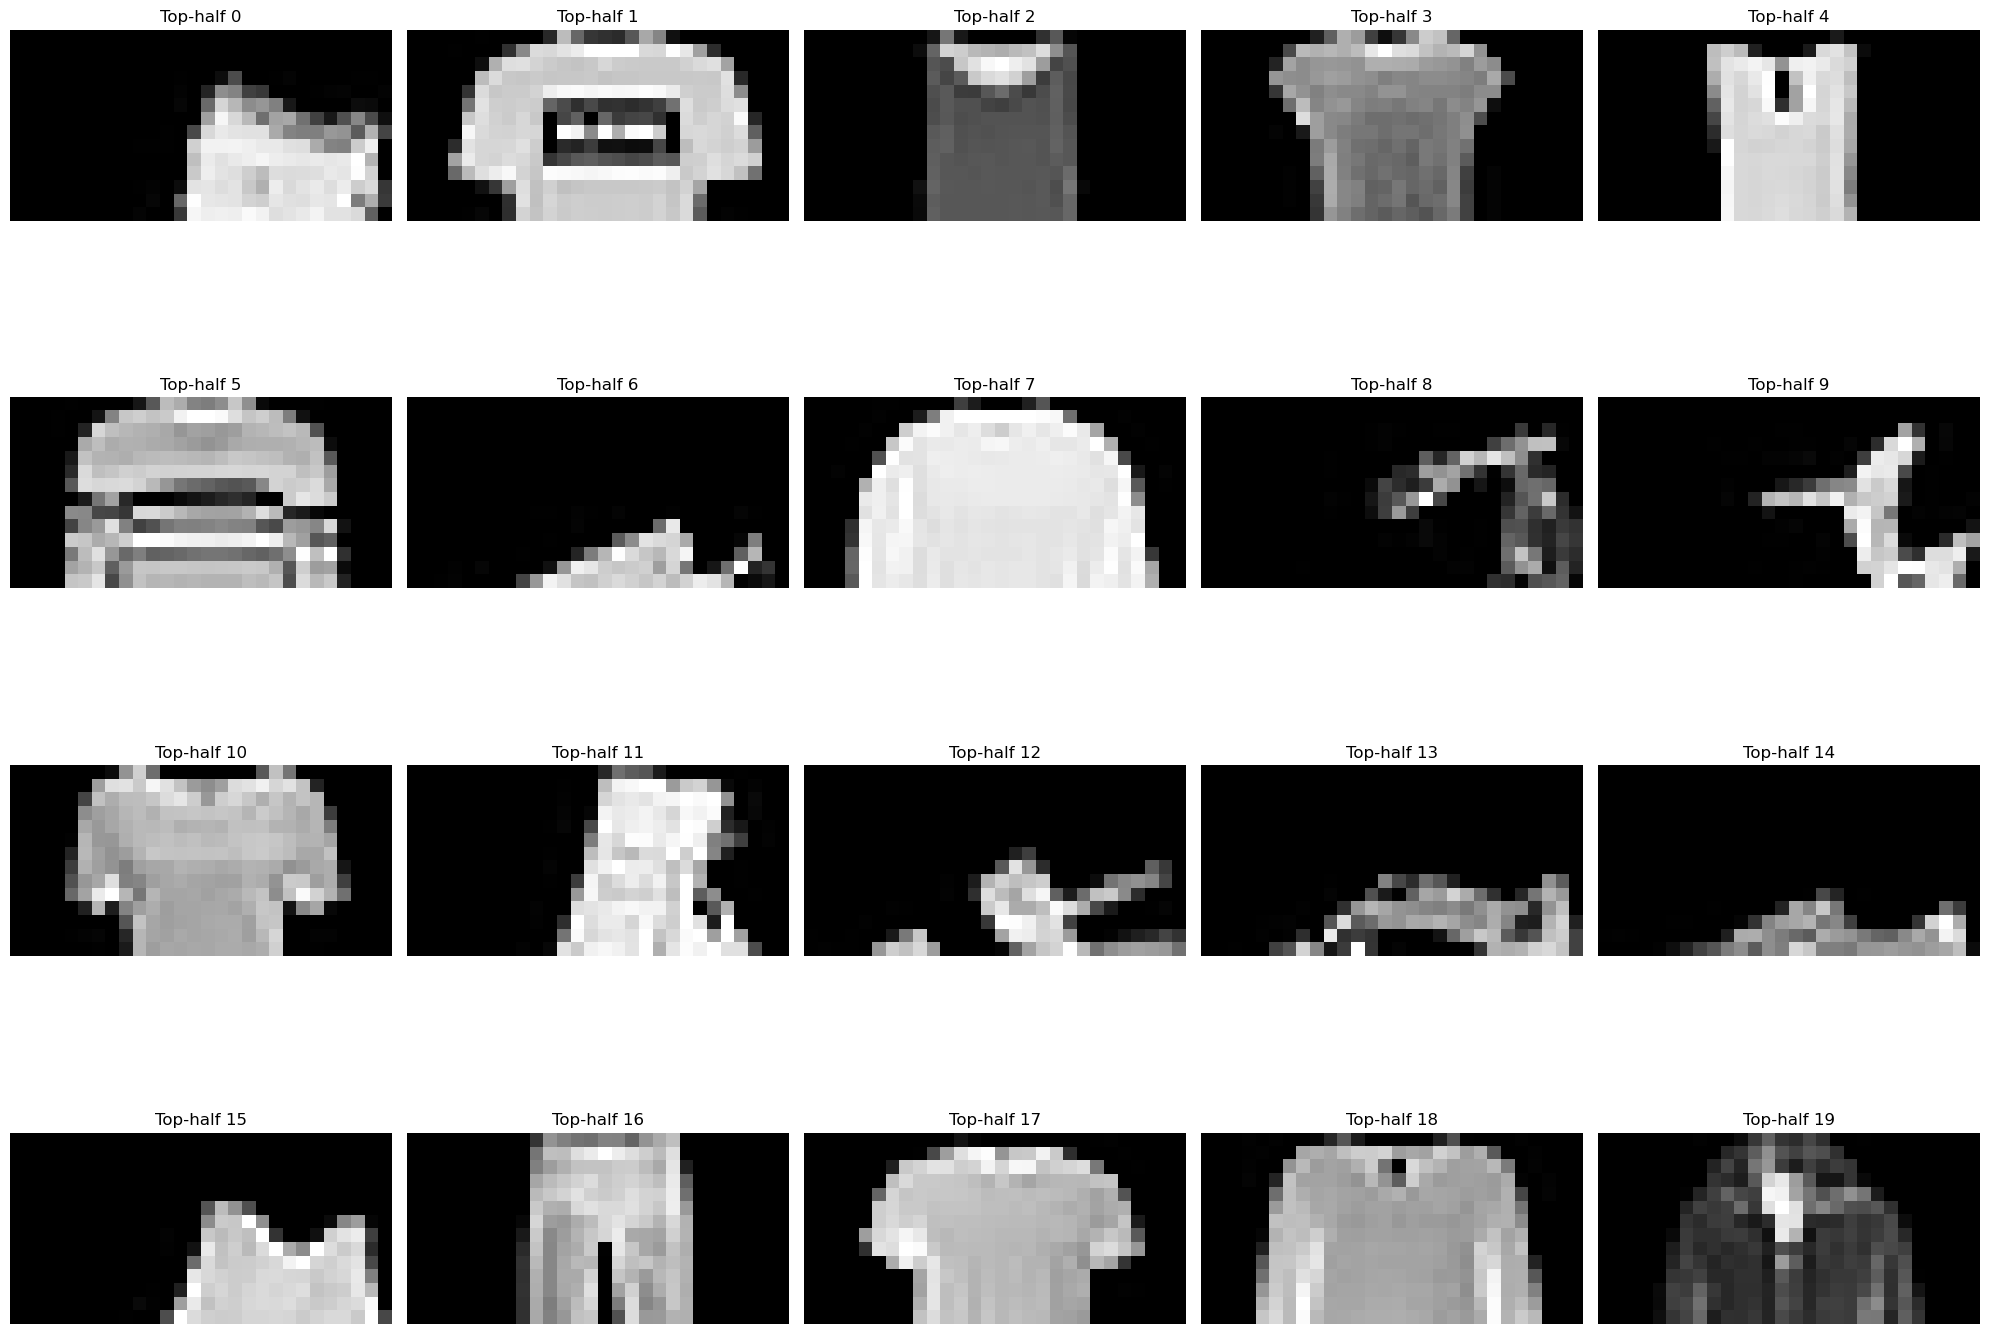

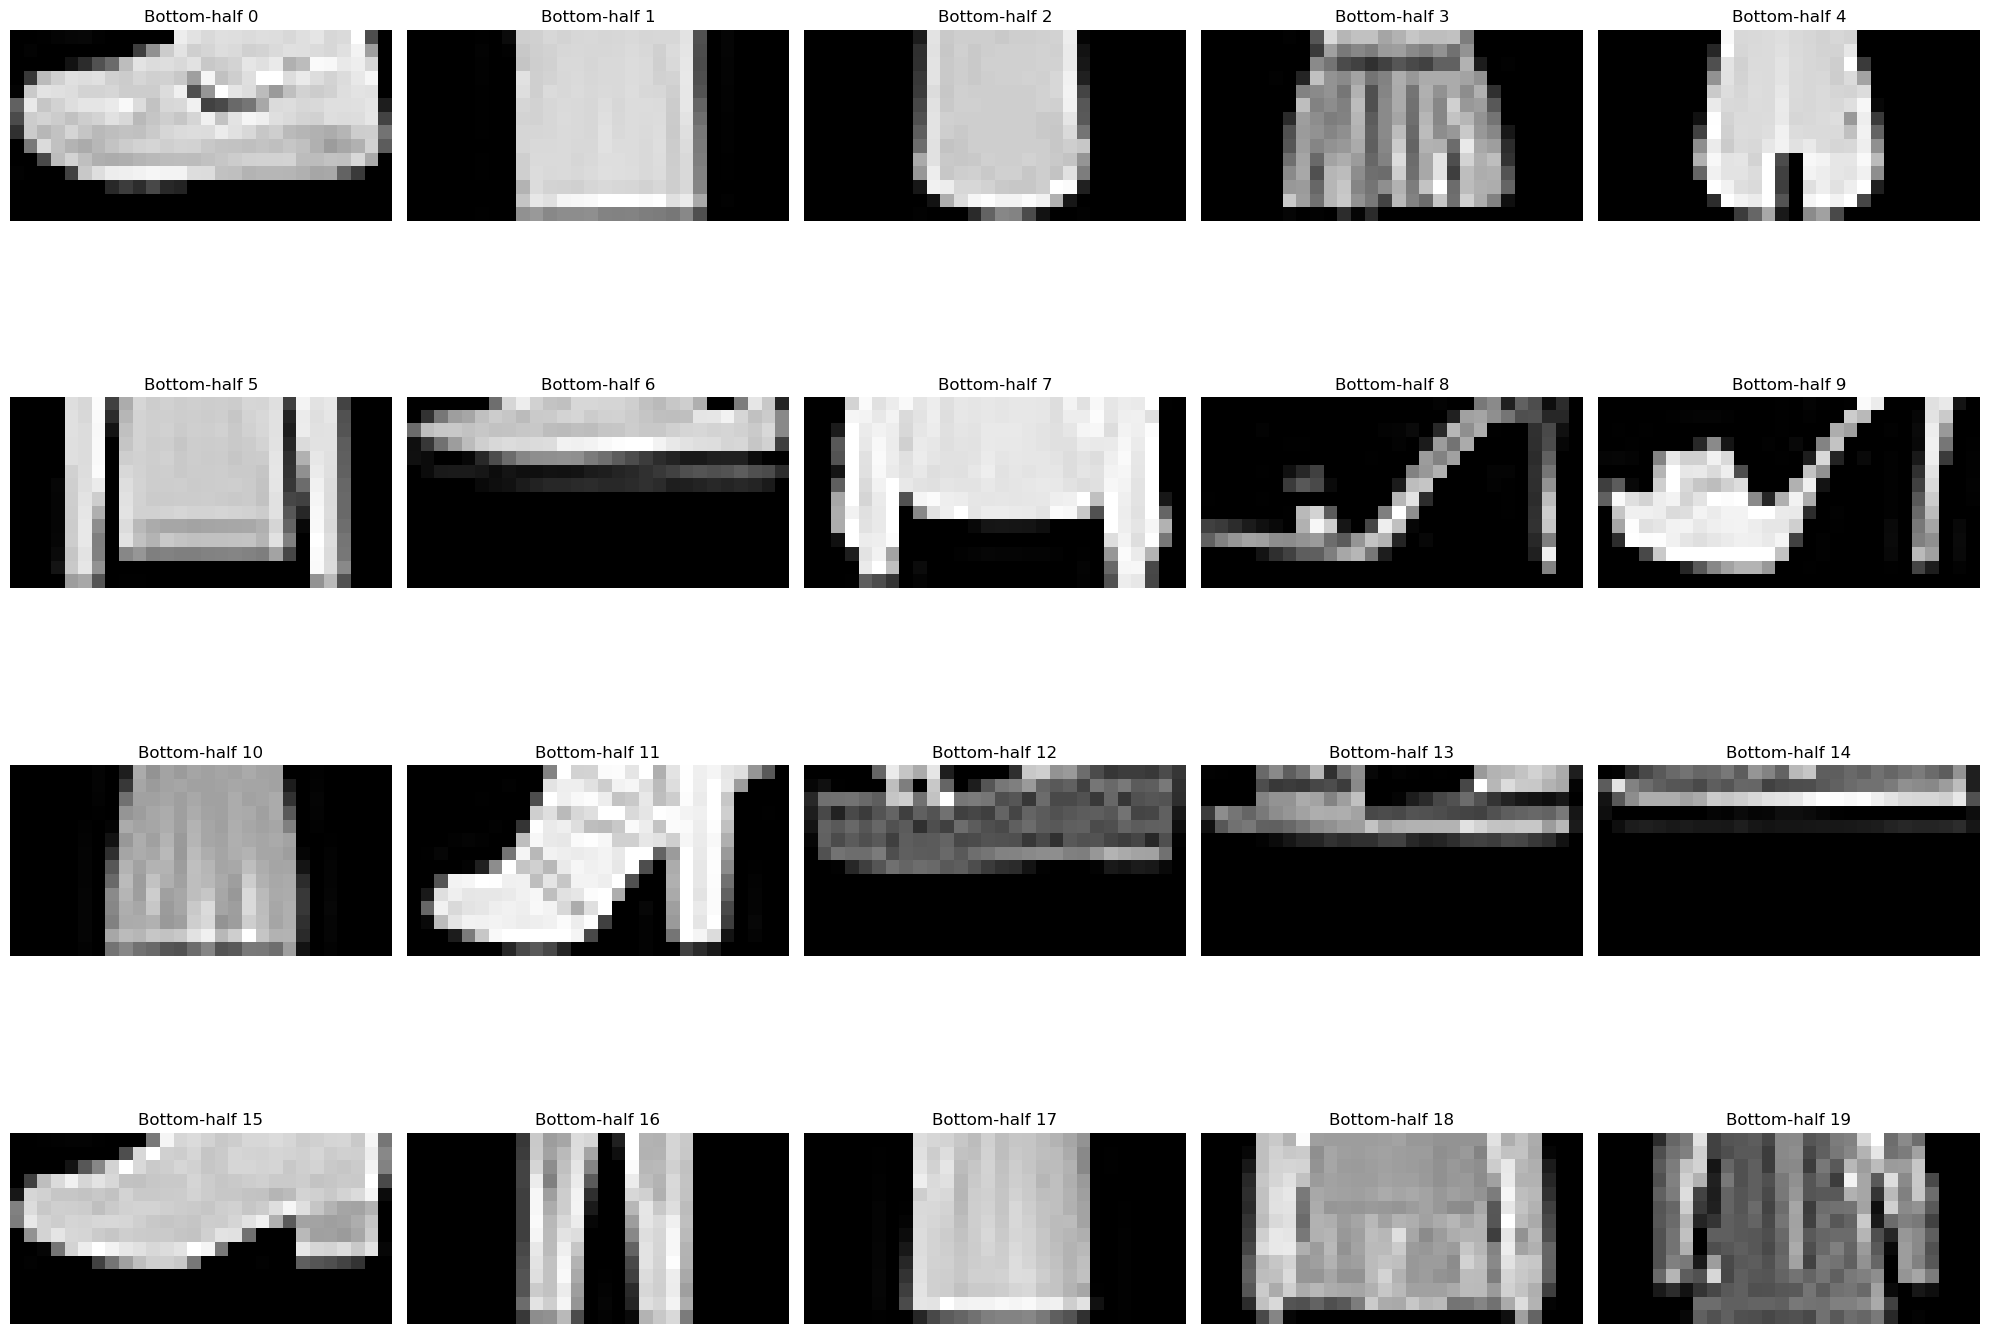

<Figure size 640x480 with 0 Axes>

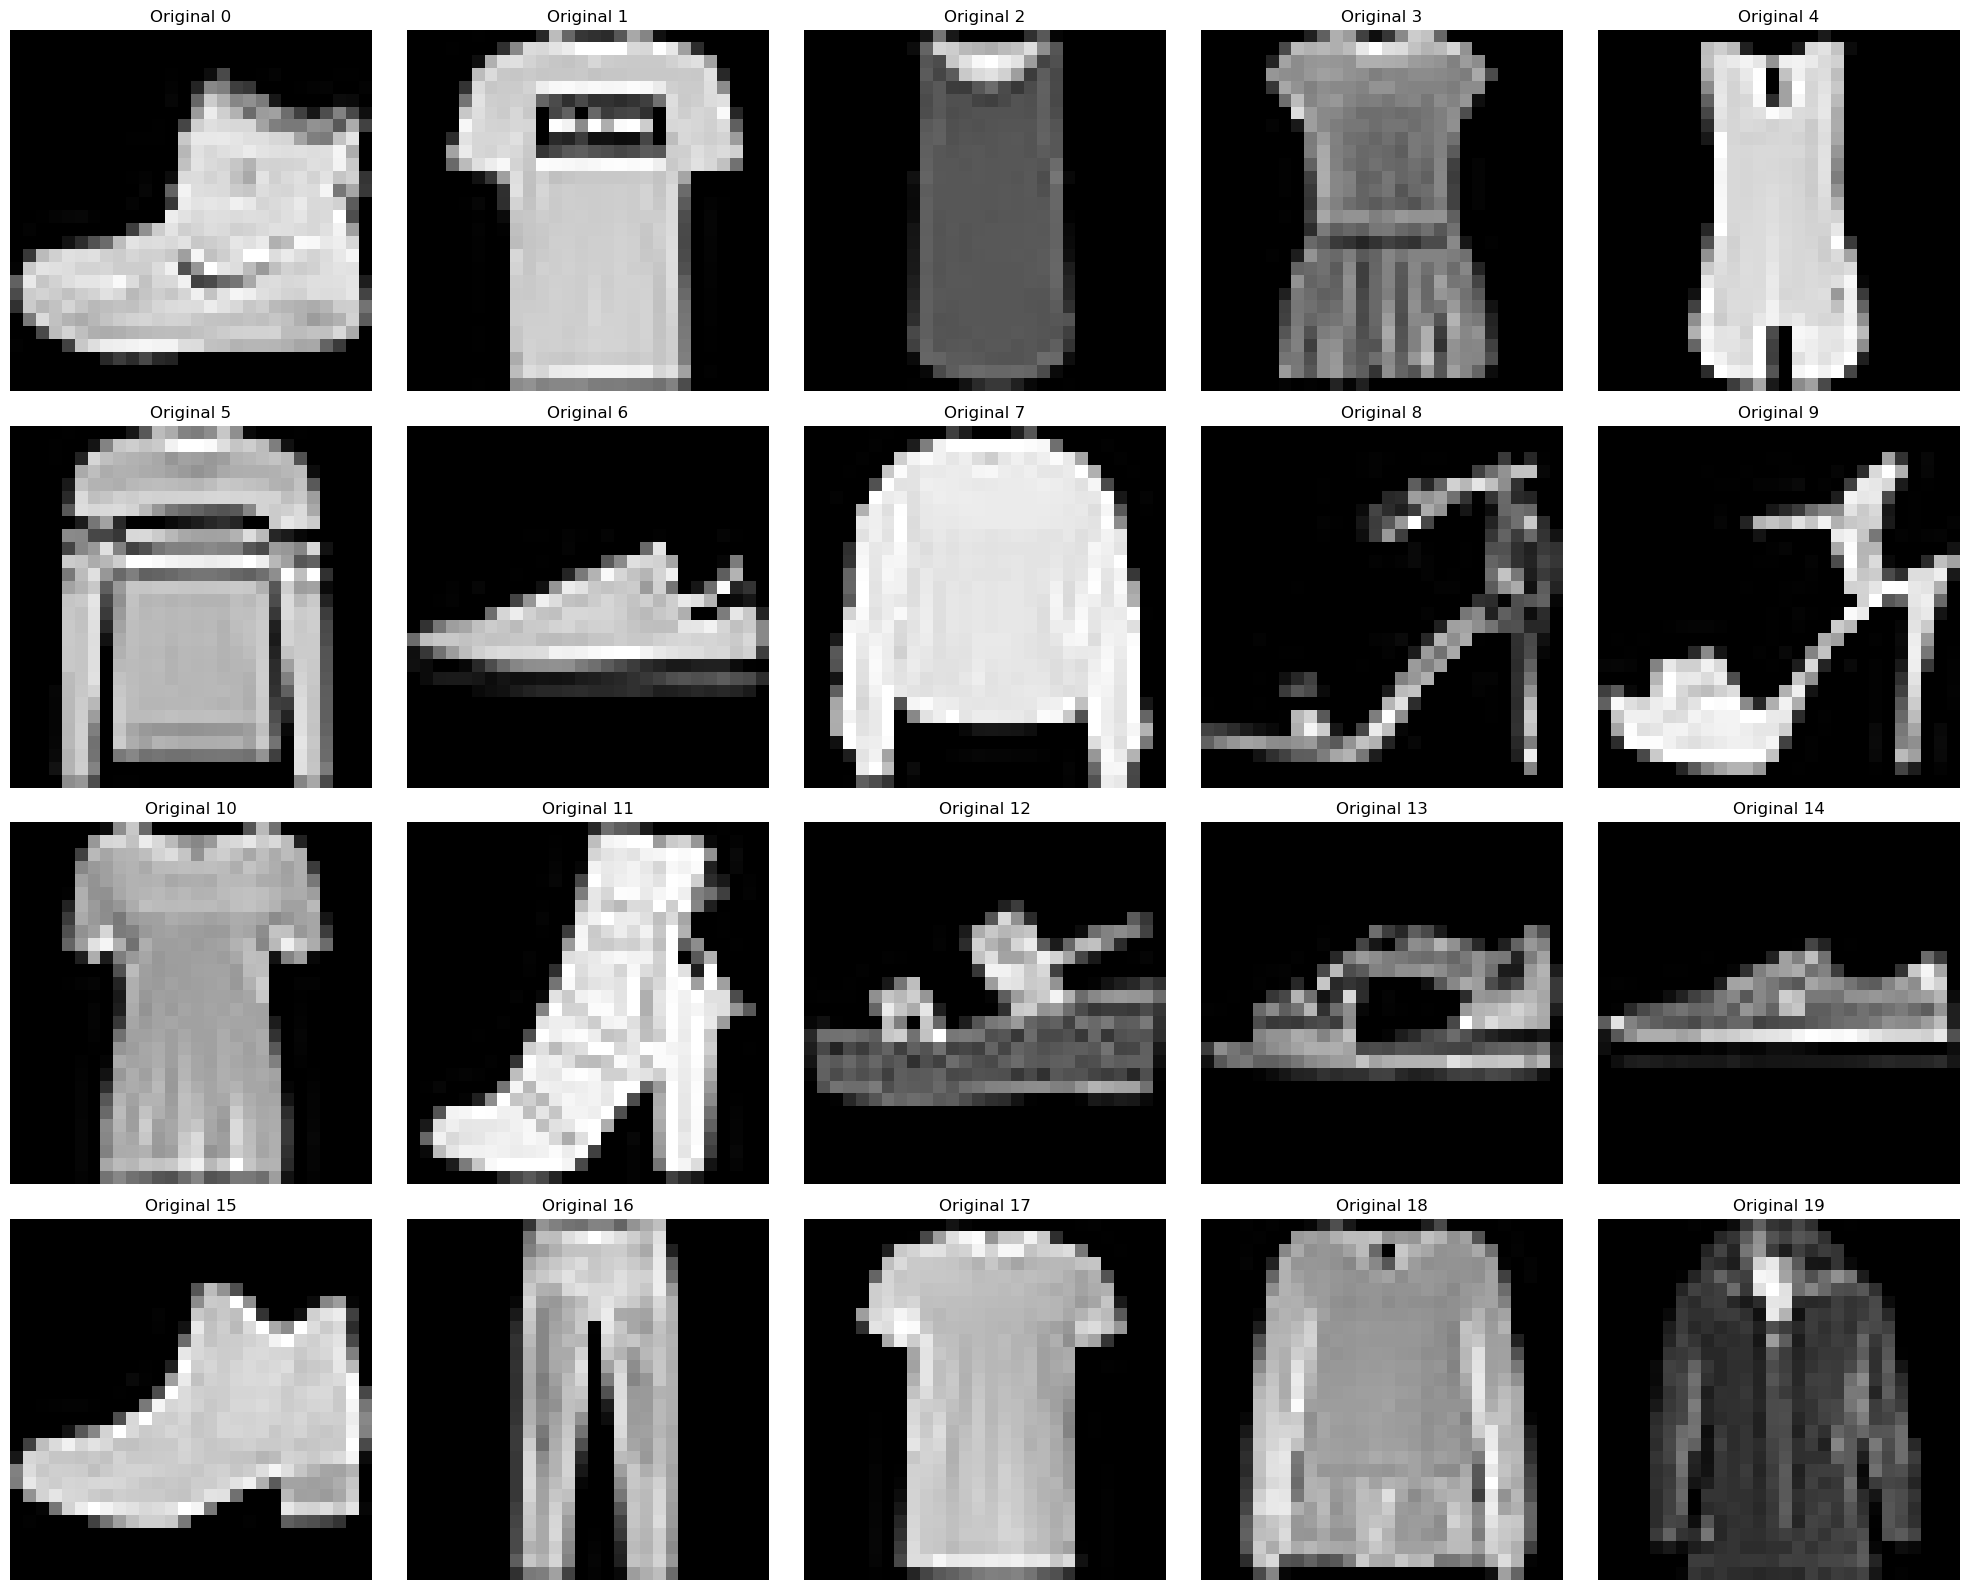

In [ ]:


# Create a figure with 4 rows and 5 columns
fig, axes = plt.subplots(4, 5, figsize=(20, 16))

# Loop through the first 20 instances for the top-half
for i in range(20):
    # Calculate the row and column index for the current instance
    row = i // 5  # Row index (0 to 3)
    col = i % 5   # Column index (0 to 4)
    
    # Plot the top-half image
    axes[row, col].imshow(X_train_top[i, :, :, 0], cmap='gray')
    axes[row, col].set_title(f'Top-half {i}')
    axes[row, col].axis('off')
    
# Print the results for the fist 20 top-half instances
plt.tight_layout()
plt.show()

# Create a figure with 4 rows and 5 columns 
fig, axes = plt.subplots(4, 5, figsize=(20, 16))

# Loop through the first 20 instances
for i in range(20):
    # Calculate the row and column index for the current instance
    row = i // 5  
    col = i % 5   
    
    # Plot the bottom-half image
    axes[row, col].imshow(X_train_bottom[i, :, :, 0], cmap='gray')
    axes[row, col].set_title(f'Bottom-half {i}')
    axes[row, col].axis('off')
    
# Print the results for the fist 20 bottom-half instances
plt.tight_layout()
plt.show()

# Print the results for the fist 20 original images
plt.tight_layout()
plt.show()

# Create a figure with 4 rows and 5 columns 
fig, axes = plt.subplots(4, 5, figsize=(20, 16))

# Loop through the first 20 instances
for i in range(20):
    # Calculate the row and column index for the current instance
    row = i // 5  
    col = i % 5   
    
    # Plot the originals images
    axes[row, col].imshow(X_train[i, :, :, 0], cmap='gray')
    axes[row, col].set_title(f'Original {i}')
    axes[row, col].axis('off')
    
# Print the results for the fist 20 original images
plt.tight_layout()
plt.show()


The split is correct. We are able to verify visually, with the last print of the first 20 original pictures, that the top-half of the image tha ise labeld top-half 0 and bottom-half 0 images are matching the original image Original 0.

In [ ]:
# a function tha return the neural neteork model

def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(14, 28, 1)),
        tf.keras.layers.Flatten(), 
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return model

model = create_model()
# Compile the model with the SGD optimizer
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=1e-4),  
    loss='sparse_categorical_crossentropy',  
    metrics=['accuracy']  
)

# Print a summary of the model
model.summary()

Model: "sequential_15"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_14 (Conv2D)          (None, 12, 26, 32)        320       
                                                                 
 flatten_15 (Flatten)        (None, 9984)              0         
                                                                 
 dense_59 (Dense)            (None, 128)               1278080   
                                                                 
 dense_60 (Dense)            (None, 64)                8256      
                                                                 
 dense_61 (Dense)            (None, 10)                650       
                                                                 
Total params: 1287306 (4.91 MB)
Trainable params: 1287306 (4.91 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


The model has 2 hiden layers of neurons the first with 128 neurons and the second with 64 neurons. 


In [56]:
#get and store the initial weight od the model

initial_weights = model.get_weights()
print(initial_weights)

[array([[[[-1.14202619e-01, -4.67722565e-02,  7.20466226e-02,
           1.71830803e-02,  6.01500273e-04,  2.07613111e-02,
           1.34415790e-01,  8.86498243e-02, -1.31309390e-01,
          -9.23957080e-02, -2.80292332e-03, -4.04021516e-02,
           4.30828482e-02,  1.03370324e-01,  4.49315012e-02,
          -6.09918982e-02,  1.17850438e-01,  3.84457707e-02,
          -2.22033262e-02, -1.21970981e-01, -3.93531695e-02,
           1.37107059e-01,  9.13398713e-02, -1.06928326e-01,
           1.01098448e-01, -5.38217723e-02, -8.98350775e-03,
          -3.10814008e-02, -6.71536624e-02, -1.05688214e-01,
          -3.19723338e-02, -1.27994284e-01]],

        [[-3.57779860e-02,  2.57229358e-02, -8.09714198e-03,
          -1.11576654e-01, -1.31027848e-02, -1.58208460e-02,
           2.77512670e-02,  8.97623897e-02,  6.51551187e-02,
          -7.89571702e-02, -3.53207737e-02, -4.31299806e-02,
           1.41931161e-01,  4.84610051e-02, -1.03017524e-01,
          -9.76620317e-02,  1.2710242

In [57]:

# Train the model on the top-half images
print("Training on top-half images...")
model.set_weights(initial_weights)  
history_top = model.fit(
    X_train_top, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_valid_top, y_valid)
    
)

# Evaluate the model on the top-half test set
y_pred_top = model.predict(X_test_top)
y_pred_top = np.argmax(y_pred_top, axis=1)
print("Classification Report for Top-Half Model:")
print(classification_report(y_test, y_pred_top))

Training on top-half images...
Epoch 1/10
1563/1563 [==============================] - 15s 9ms/step - loss: 2.2819 - accuracy: 0.2013 - val_loss: 2.3050 - val_accuracy: 0.0968
Epoch 2/10
1563/1563 [==============================] - 14s 9ms/step - loss: 2.2191 - accuracy: 0.3403 - val_loss: 2.3089 - val_accuracy: 0.1015
Epoch 3/10
1563/1563 [==============================] - 15s 10ms/step - loss: 2.1447 - accuracy: 0.4035 - val_loss: 2.3184 - val_accuracy: 0.1047
Epoch 4/10
1563/1563 [==============================] - 14s 9ms/step - loss: 2.0394 - accuracy: 0.4659 - val_loss: 2.3420 - val_accuracy: 0.1014
Epoch 5/10
1563/1563 [==============================] - 14s 9ms/step - loss: 1.8894 - accuracy: 0.5172 - val_loss: 2.3987 - val_accuracy: 0.1044
Epoch 6/10
1563/1563 [==============================] - 15s 10ms/step - loss: 1.7004 - accuracy: 0.5487 - val_loss: 2.5228 - val_accuracy: 0.1045
Epoch 7/10
1563/1563 [==============================] - 16s 10ms/step - loss: 1.5107 - accuracy: 

For the first model with the top half image we observe tha the model perfom deferently among the classes. WE have classes with high precision, recall and f1 score like class 1, 7, 8 and 9 and poorly or moderate results in other classes.  The best perfoming class is the class 8 with 0.80 precision 0.88 recall and 0.84 f1/score. Tha means the model predict correct the 80% of the images, high recall indicates fewer falsh negative, and higher f1.score indicates better perfomance. In the other hand the model perfom poorly for class 5 and 6. At calss 6 we have the lower values in precision and f1/score and recall so the model is faling to make correct prediction for this class and at class five we have 91% prediction with 0.12% recall that means the model is not identifiy a lot true possitives. The model overall accuracy is 61% and that indicate there is a room for improvment. 

In [58]:
# Reset the model's weights
model.set_weights(initial_weights)

# Train the model on the bottom-half images
print("Training on bottom-half images...")
history_bottom = model.fit(
    X_train_bottom, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_valid_bottom, y_valid)
)

# Evaluate the model on the bottom-half test set
y_pred_bottom = model.predict(X_test_bottom)
y_pred_bottom = np.argmax(y_pred_bottom, axis=1)
print("Classification Report for Bottom-Half Model:")
print(classification_report(y_test, y_pred_bottom))

Training on bottom-half images...
Epoch 1/10
1563/1563 [==============================] - 14s 9ms/step - loss: 2.2629 - accuracy: 0.2364 - val_loss: 2.3101 - val_accuracy: 0.1001
Epoch 2/10
1563/1563 [==============================] - 14s 9ms/step - loss: 2.1850 - accuracy: 0.3261 - val_loss: 2.3217 - val_accuracy: 0.1007
Epoch 3/10
1563/1563 [==============================] - 14s 9ms/step - loss: 2.0938 - accuracy: 0.3458 - val_loss: 2.3464 - val_accuracy: 0.1013
Epoch 4/10
1563/1563 [==============================] - 14s 9ms/step - loss: 1.9697 - accuracy: 0.3788 - val_loss: 2.3978 - val_accuracy: 0.1007
Epoch 5/10
1563/1563 [==============================] - 14s 9ms/step - loss: 1.8120 - accuracy: 0.4307 - val_loss: 2.4940 - val_accuracy: 0.1011
Epoch 6/10
1563/1563 [==============================] - 14s 9ms/step - loss: 1.6415 - accuracy: 0.5080 - val_loss: 2.6459 - val_accuracy: 0.1009
Epoch 7/10
1563/1563 [==============================] - 14s 9ms/step - loss: 1.4838 - accuracy: 

For the bottom half images the model performace is similar to the previus model for the top half images the 59% accuracy is sligthly worst than top-half model. We have again some classes that the model performing well and other with lower or moderate results. Both of the model are strungled to make prediction for the classes 5,6. At class 5 we habe high precision but very low recall simmilar result with the top half,definatly the model is not perfoming well for this specific class. The result for class 1 ,3, 8 and 9 are perfoming well . Conclusion both model are inballanced with moderete accuracy that indicates there is a room for improvment.

313/313 [==============================] - 1s 3ms/step


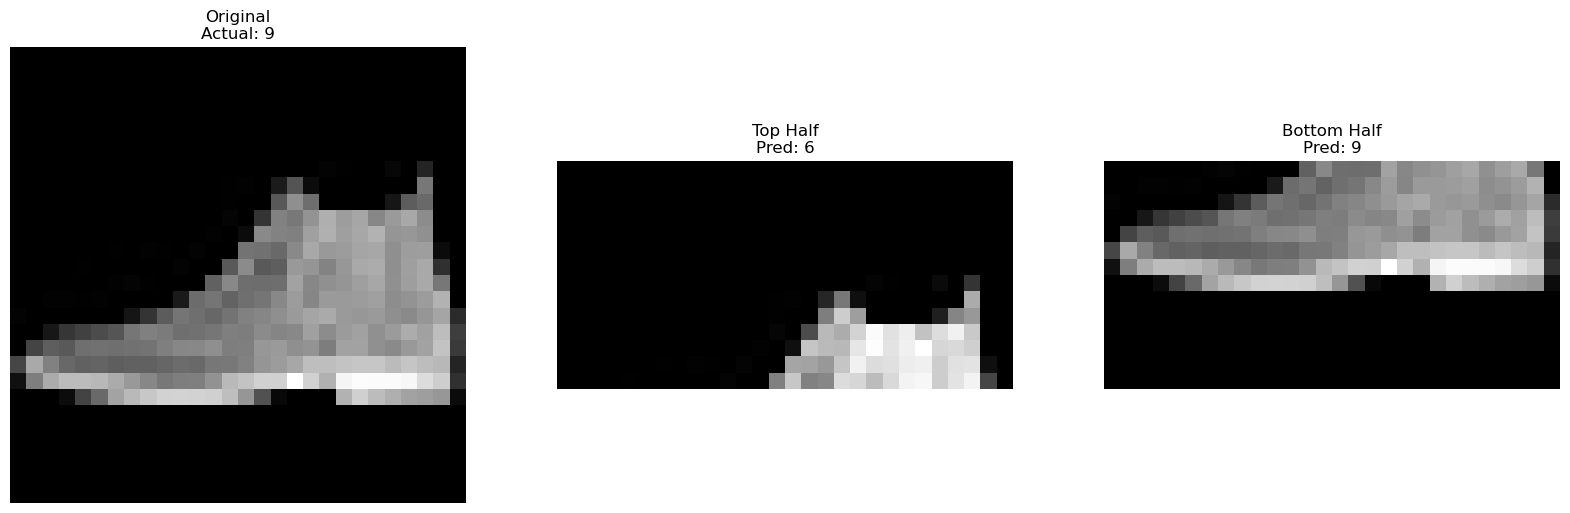

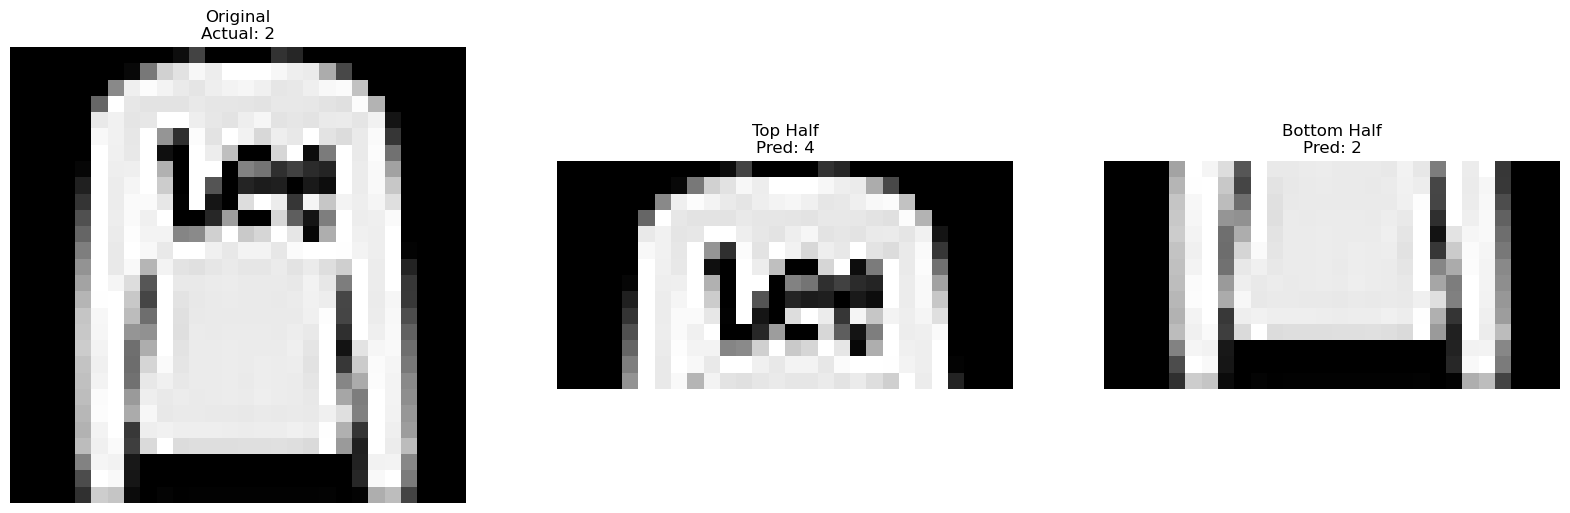

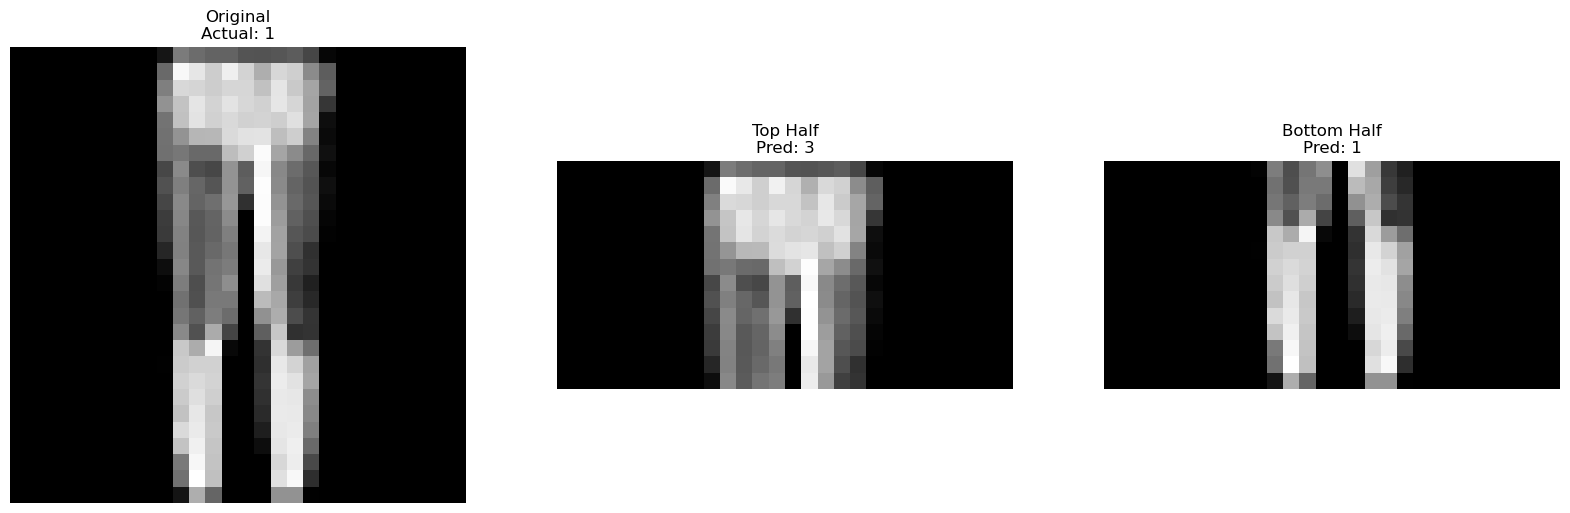

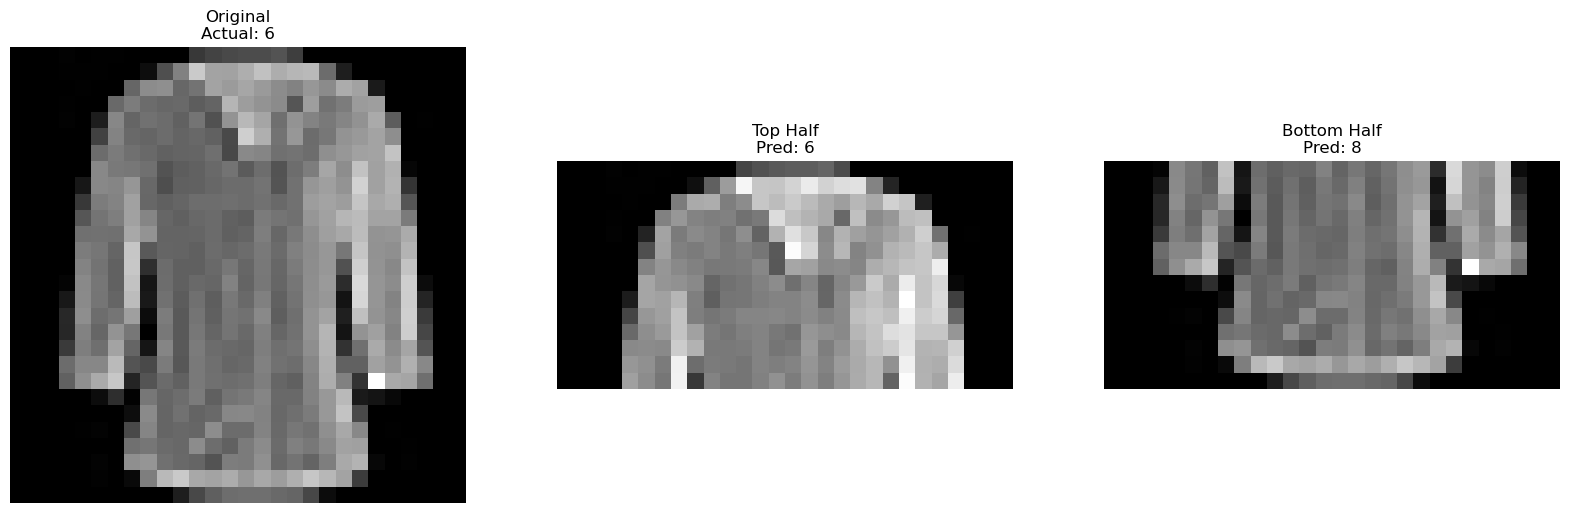

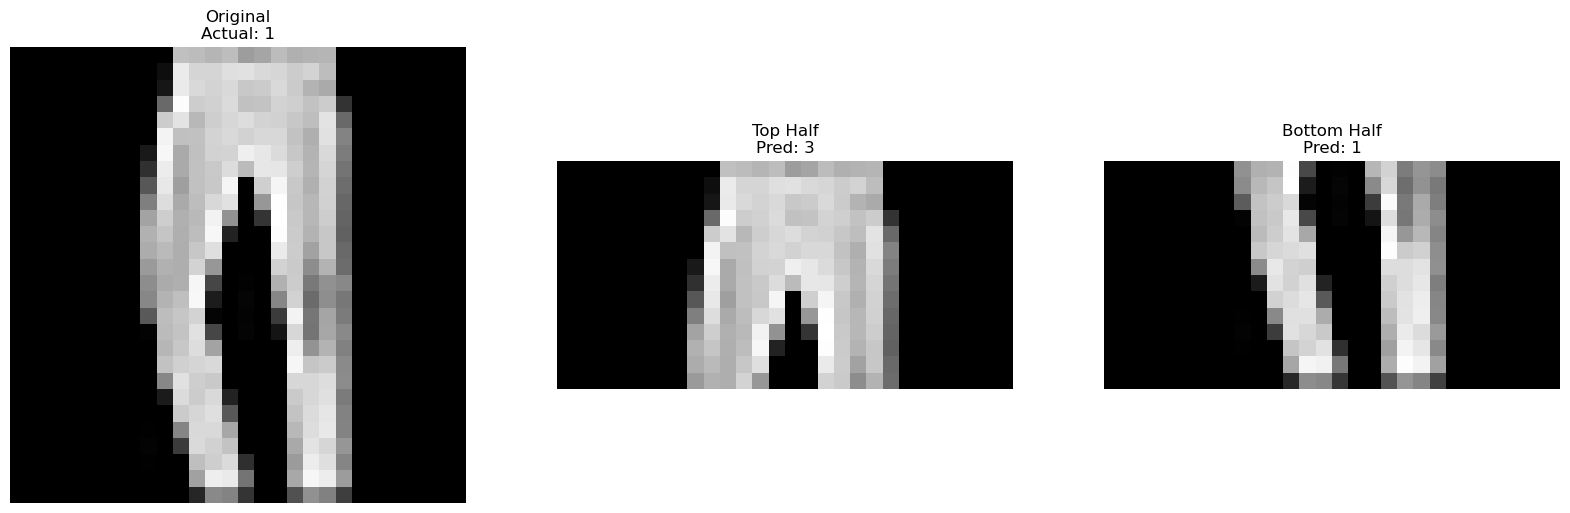

In [ ]:

# Get predictions from both models
y_pred_top = np.argmax(model.predict(X_test_top), axis=1)
y_pred_bottom = np.argmax(model.predict(X_test_bottom), axis=1)

# Identify instances where one model is correct and the other is incorrect
falsh_prediction = []
for i in range(len(y_test)):
    if (y_pred_top[i] == y_test[i] and y_pred_bottom[i] != y_test[i]) or \
       (y_pred_bottom[i] == y_test[i] and y_pred_top[i] != y_test[i]):
        falsh_prediction.append(i)

# Display the first 5 mismatch instances
for i in falsh_prediction[:5]:
    plt.figure(figsize=(20, 16))
    
    # Plot the original image
    plt.subplot(1, 3, 1)
    plt.imshow(X_test[i, :, :, 0], cmap='gray')
    plt.title(f'Original\nActual: {y_test[i]}')
    plt.axis('off')
    
    # Plot the top-half image and prediction
    plt.subplot(1, 3, 2)
    plt.imshow(X_test_top[i, :, :, 0], cmap='gray')
    plt.title(f'Top Half\nPred: {y_pred_top[i]}')
    plt.axis('off')
    
    # Plot the bottom-half image and prediction
    plt.subplot(1, 3, 3)
    plt.imshow(X_test_bottom[i, :, :, 0], cmap='gray')
    plt.title(f'Bottom Half\nPred: {y_pred_bottom[i]}')
    plt.axis('off')
    
    plt.show()

 Image (1) For the first set of images the actual class is 9 the bottom half predict the correct class and the top half failed to indentify the correct class because the image provide signifitant lower ammount of imformation as the other class.
 Image (2) at the second set of images the actual class is 2 the top half predict the wrong class and the bottom half the correct class because the top class inludes more general information and the bottom more spesific (in this case long sleeves)
 Image (3) at the third set of images the actual class is 1 the top half predict the wrong class and the bottom half the correct class because the top class inludes more general information and the bottom more spesific (in this case long trauser)
 Image (4) For the forth set of images the actual class is 6 the top half predict the right class and the bottom has indentify the wrong class because the image provide signifitant more ammount of imformation as the other class.
 Image (5) For the fifth set of images the actual class is 1 the top half predict the wrong class and the bottom half has indentify the correct class because the image provide more generalized informations  (in this case long trauser)

Model: "sequential_16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_15 (Conv2D)          (None, 12, 26, 32)        320       
                                                                 
 flatten_16 (Flatten)        (None, 9984)              0         
                                                                 
 dense_62 (Dense)            (None, 128)               1278080   
                                                                 
 dense_63 (Dense)            (None, 64)                8256      
                                                                 
 dense_64 (Dense)            (None, 32)                2080      
                                                                 
 dense_65 (Dense)            (None, 10)                330       
                                                                 
Total params: 1289066 (4.92 MB)
Trainable params: 128

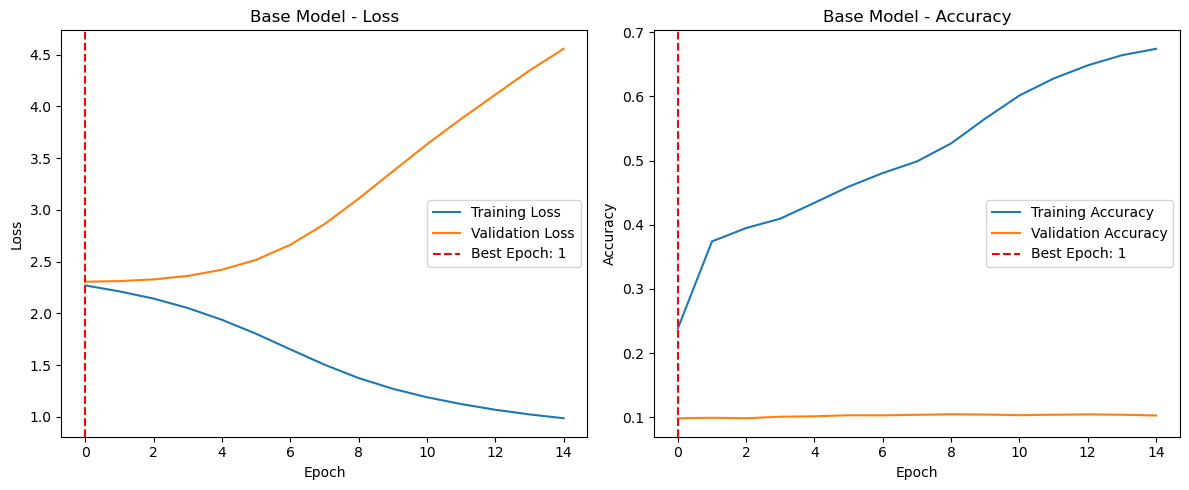

In [60]:
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(14, 28, 1)),
        tf.keras.layers.Flatten(), 
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return model

model_2 = create_model()
# Compile the model
model_2.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=1e-4),  
    loss='sparse_categorical_crossentropy',  
    metrics=['accuracy']  
)

# Print a summary of the model
model_2.summary()

# Train the base model
print("Training the base model...")
history_base = model_2.fit(
    X_train_top, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_valid_top, y_valid)
)

# Function to plot training and validation metrics
def plot_metrics(history, title):
    plt.figure(figsize=(12, 5))
    
    # Plot training and validation loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    # Highlight the best epoch (epoch with the lowest validation loss)
    best_epoch = np.argmin(history.history['val_loss'])
    plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Epoch: {best_epoch + 1}')
    plt.legend()
    
    # Plot training and validation accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # Highlight the best epoch
    plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Epoch: {best_epoch + 1}')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Function to generate and print classification report
def generate_classification_report(model, x_test, y_test):
    y_pred = np.argmax(model.predict(x_test), axis=1)
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

# Evaluate the base model
generate_classification_report(model_2, X_test_top, y_test)
plot_metrics(history_base, "Base Model")



The base model has a third hiden layer with neurons in combarison with the first model and the results are slightlty better with 67% accuracy, best epoch is the epoch 1.But the model is not performing well the accuracy is improving but the classification report show us tha the model is not performing well in all the classes. The model is overfitting the training data and it fails to generalized at the validation set. The validation accuracy is only 10%, again the model is performing poorlz at class 5 and 6. From the figure we also observe tha the validation loss is increasing and the training loss is decreasing that also means the model is overfitting tha data. 

Model: "sequential_17"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_16 (Conv2D)          (None, 12, 26, 32)        320       
                                                                 
 flatten_17 (Flatten)        (None, 9984)              0         
                                                                 
 dense_66 (Dense)            (None, 128)               1278080   
                                                                 
 dense_67 (Dense)            (None, 64)                8256      
                                                                 
 dense_68 (Dense)            (None, 32)                2080      
                                                                 
 dense_69 (Dense)            (None, 10)                330       
                                                                 
Total params: 1289066 (4.92 MB)
Trainable params: 128

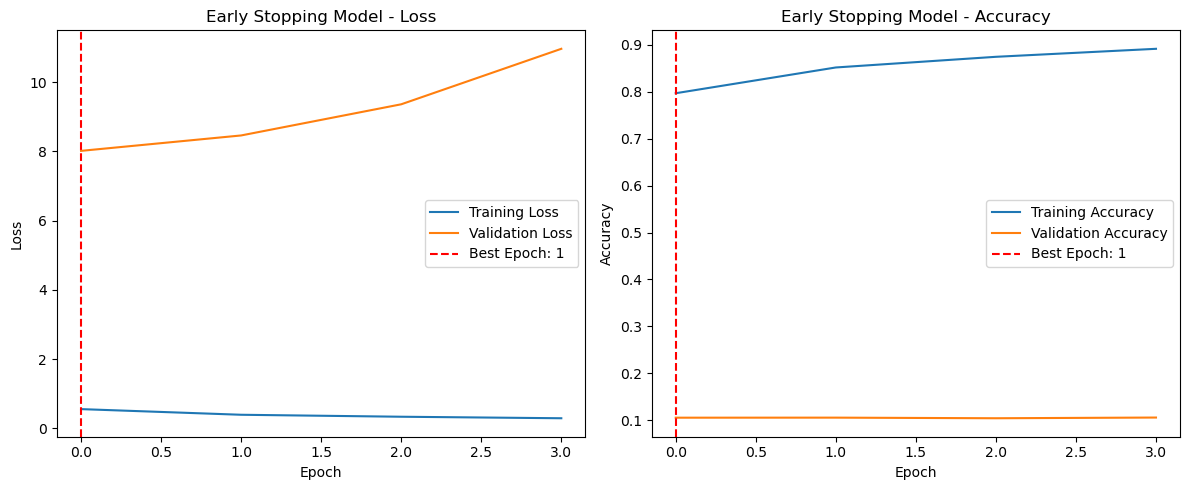

In [ ]:


# Rebuild the base model
early_stopping_model = create_model()

# Compile the model
early_stopping_model.compile(
    optimizer='adam',  
    loss='sparse_categorical_crossentropy',  
    metrics=['accuracy']  
)
# Define early stopping callback
early_stopping_callback = EarlyStopping(
    monitor='val_loss',  
    patience=3,         
    restore_best_weights=True  
)

# Print a summary of the model
early_stopping_model.summary()

# Train the model with early stopping
print("Training the model with early stopping...")
history_early_stopping = early_stopping_model.fit(
    X_train_top, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_valid_top, y_valid),
    callbacks=[early_stopping_callback]  
)

# Evaluate the model with early stopping
generate_classification_report(early_stopping_model, X_test_top, y_test)
plot_metrics(history_early_stopping, "Early Stopping Model")

The early stopping model has significatly increase the accuracy to 83% and stops improving the accuracy to prevent overfiting the data. The validation loss is increasing in every epoch so the model stops at epoch 4 (we have set the patience at 3). The Modell is performing well at training data in all classes but is still failes to generalized the data the Validation accuracy is still at 10%. The model with the early stoping is performing better in terms of accuracy but still overfitting the data

Model: "sequential_18"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_17 (Conv2D)          (None, 12, 26, 32)        320       
                                                                 
 flatten_18 (Flatten)        (None, 9984)              0         
                                                                 
 dense_70 (Dense)            (None, 128)               1277952   
                                                                 
 batch_normalization_12 (Ba  (None, 128)               512       
 tchNormalization)                                               
                                                                 
 dense_71 (Dense)            (None, 64)                8192      
                                                                 
 batch_normalization_13 (Ba  (None, 64)                256       
 tchNormalization)                                   

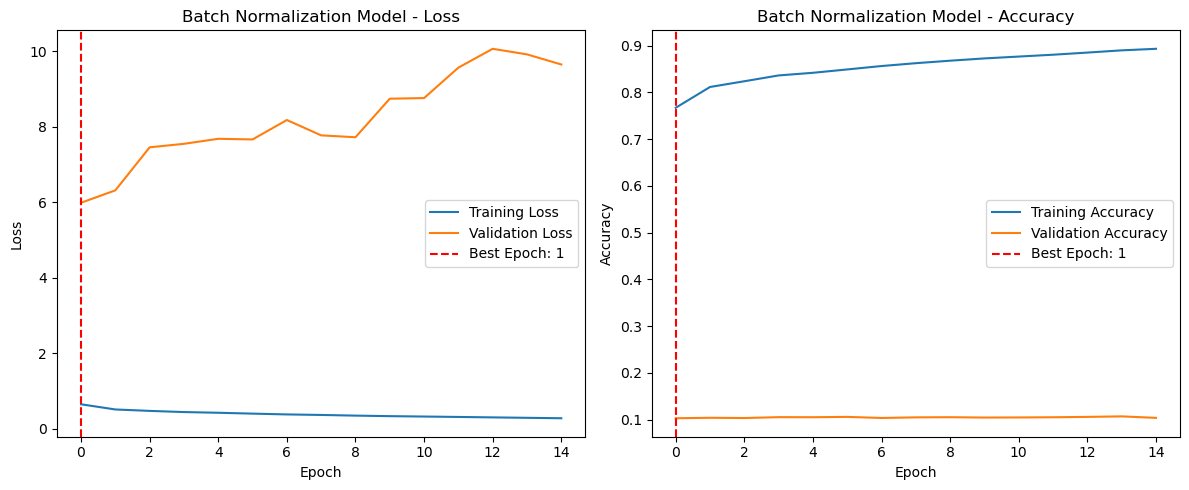

In [ ]:


# Define the base model with batch normalization
def create_batch_normalization_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), input_shape=(14, 28, 1)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu', use_bias=False),  
        BatchNormalization(),  
        tf.keras.layers.Dense(64, activation='relu', use_bias=False),   
        BatchNormalization(), 
        tf.keras.layers.Dense(32, activation='relu', use_bias=False),  
        BatchNormalization(),  
        tf.keras.layers.Dense(10, activation='softmax')  
    ])
    return model

# Create the batch normalization model
batch_normalization_model = create_batch_normalization_model()

# Compile the batch normalization model
batch_normalization_model.compile(
    optimizer='adam',  
    loss='sparse_categorical_crossentropy',  #
    metrics=['accuracy']  
)


# Print a summary of the model
batch_normalization_model.summary()

# Train the batch normalization model
print("Training the batch normalization model...")
history_batch_normalization_model = batch_normalization_model.fit(
    X_train_top, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_valid_top, y_valid)
)

# Evaluate the batch normalization model
generate_classification_report(batch_normalization_model, X_test_top, y_test)
plot_metrics(history_batch_normalization_model, "Batch Normalization Model")

At the model with the bath normalaization the accuracy of the model is not redunced neither increased the overall accuracy is 84%. We have a lot o differences in memory the bath model is uding more memory than the previus model, and the amound of time for the data to be preccessed is also incresead. The other results are similar to the previus models, the model still overfitting the data, but in term of accuracy it perform better is all the classes exept class 6, tha validation accuracy is still low at 10%

Model: "sequential_19"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_18 (Conv2D)          (None, 12, 26, 32)        320       
                                                                 
 flatten_19 (Flatten)        (None, 9984)              0         
                                                                 
 dense_74 (Dense)            (None, 128)               1278080   
                                                                 
 dropout_15 (Dropout)        (None, 128)               0         
                                                                 
 dense_75 (Dense)            (None, 64)                8256      
                                                                 
 dropout_16 (Dropout)        (None, 64)                0         
                                                                 
 dense_76 (Dense)            (None, 32)              

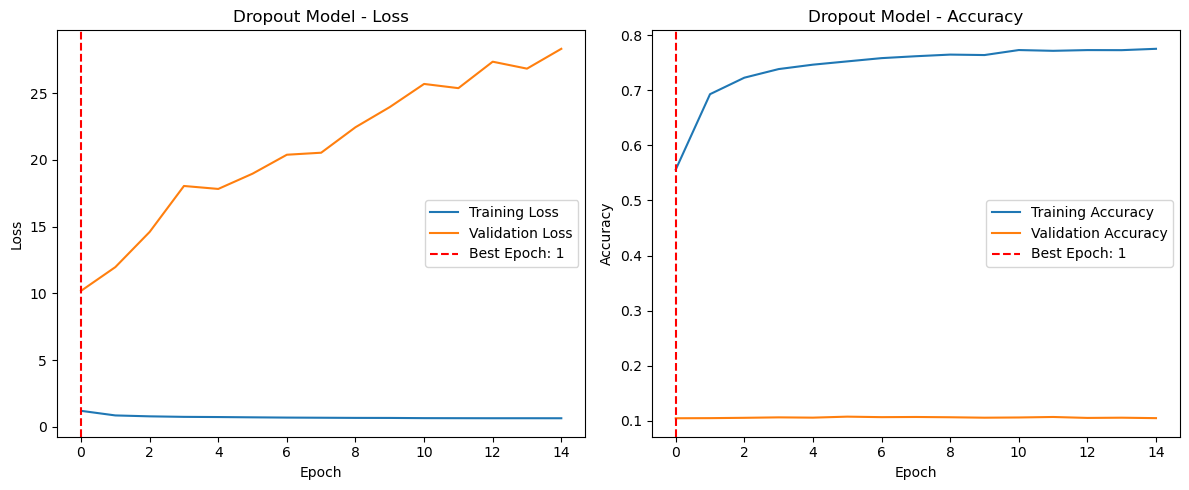

In [ ]:


# Define the base model with dropout
def create_dropout_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), input_shape=(14, 28, 1)),
        tf.keras.layers.Flatten(),  
        tf.keras.layers.Dense(128, activation='relu'),     
        Dropout(0.50),  
        tf.keras.layers.Dense(64, activation='relu'),      
        Dropout(0.50),  
        tf.keras.layers.Dense(32, activation='relu'),      
        Dropout(0.50),  
        tf.keras.layers.Dense(10, activation='softmax')    
    ])
    return model

# Create the dropout model
dropout_model = create_dropout_model()

# Compile the dropout model
dropout_model.compile(
    optimizer='adam',  
    loss='sparse_categorical_crossentropy',  
    metrics=['accuracy']  
)

# Print a summary of the model
dropout_model.summary()

# Train the dropout model
print("Training the dropout model...")
history_dropout = dropout_model.fit(
    X_train_top, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_valid_top, y_valid)
)

# Evaluate the dropout model
generate_classification_report(dropout_model, X_test_top, y_test)
plot_metrics(history_dropout, "Dropout Model")

The last model is not performing also well, the overall accuracy is ta 80%, the model is still overfitting the data and the validation accuracy at the validation set is at 10%.

If we compare the last 4 models we are able to conlude the followings. In terms of memory usage all the models are using 4.92 MB of total parameters, 4.9 MB of trainable parameters exept of the batch normalization model tha is using an extra 1,75 MB of Non-trainable parameters. The base model was faster in data processing at every epoch with avarage 13 sec/epoch and 8 ms/ pro step. The erly stoping model was faster than the ohters but it only stoped at 4 epochs with 17 ms/step and 25-27 sec for each epoch and also has the best accuracy performans because was stop to prevent overfitting. The batch normalazation and the droupout model are also performing in the alsmot the same times with the dropoutmodel to be 1 sec slower tha the batch model. The Base model has score the lowest accuracy of all but the other 3 problems exept of the accurancy improvment still failed to generalize the data and prevent overfitting. The early stoping model was also the model that had perfomed well in all the groups of data improving the accuracy in class 5 and 6 that other models are strungling. In my opiniin the early stoping model was best perform but is more space from improvment in order to solve the overfitting problem.